In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00



Inicialización de YOLOv11s

In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11s.pt", task='detect')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


extraccion de los datos del .zip al entorno

In [ ]:
import zipfile
import os

# Assuming the zip file is already uploaded directly to the Colab environment.
# Please replace 'your_dataset.zip' with the actual name of your zip file.
zip_filename = '/content/YOLOV4.v1-v4.yolov8.zip' # <---- IMPORTANT: Change this to your uploaded zip file name

# Create a directory to extract the dataset
dataset_dir_name = os.path.splitext(zip_filename)[0] # Use the zip filename without extension as the directory name
!mkdir -p {dataset_dir_name}

# Unzip the uploaded file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir_name)

# Define a mock dataset object for consistency with downstream cells
class MockDataset:
    def __init__(self, location):
        self.location = location

# Assuming the extracted data.yaml is directly under the extracted folder
dataset = MockDataset(location=dataset_dir_name)

print(f"Dataset extracted to: {dataset.location}")
print(f"You can now proceed with training using the local dataset.")

Dataset extracted to: /content/YOLOV4.v1-v4.yolov8
You can now proceed with training using the local dataset.


entrenamiento

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11n-seg.pt')


results = model.train(
    # Dataset
    data=f"{dataset.location}/data.yaml",
    epochs=150,
    imgsz=640,         # ← reducido de 640 (30% más rápido)
    batch=16,          # ← reducido (más estable en T4)
    cache=False,        # ← CRÍTICO: carga dataset en RAM, épocas 2-4x más rápidas
    workers=2,         # ← estable en Colab

    # Transfer learning — sin congelar nada
    freeze=0,

    # Learning rate
    optimizer="SGD",
    lr0=1e-3,
    lrf=0.01,
    warmup_epochs=3,
    warmup_bias_lr=0.1,
    momentum=0.937,
    weight_decay=0.0005,

    # Hardware
    device='CUDA',

    # AUGMENTACIÓN
    mixup=0.0,         # ← desactivado
    copy_paste=0.0,    # ← desactivado (especialmente caro en segmentación)
    fliplr=0.5,
    flipud=0.1,

    # EVALUACIÓN Y MÉTRICAS
    val=True,
    iou=0.7,
    conf=0.25,

    # GUARDADO Y MONITOREO
    plots=True,
    save_json=True,
    save_period=20,
    patience=15,

    project="manufactura",
    name="yolo_scratch_v1"
)


# RESULTADOS

print("\n===== MÉTRICAS FINALES =====")
print(f"mAP50:      {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")
print(f"mAP50-95:   {results.results_dict.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
print(f"Precisión:  {results.results_dict.get('metrics/precision(B)', 'N/A'):.4f}")
print(f"Recall:     {results.results_dict.get('metrics/recall(B)', 'N/A'):.4f}")

# Métricas específicas de segmentación
print(f"\nmAP50 (seg):    {results.results_dict.get('metrics/mAP50(M)', 'N/A'):.4f}")
print(f"mAP50-95 (seg): {results.results_dict.get('metrics/mAP50-95(M)', 'N/A'):.4f}")

# VALIDACIÓN FINAL CON UMBRALES AJUSTADOS

metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    iou=0.7,
    conf=0.25,
    plots=True,
    save_json=True,
)

Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/YOLOV4.v1-v4.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_scratch_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=T

prueba con una imagen de test


image 1/1 /content/YOLO-2/test/images/108_seg_1777308317s_png.rf.58ecd6c15c5b55219949843d556c29f3.jpg: 480x480 1 square_female_part_yellow, 1 square_male_part_yellow, 19.4ms
Speed: 3.2ms preprocess, 19.4ms inference, 8.2ms postprocess per image at shape (1, 3, 480, 480)


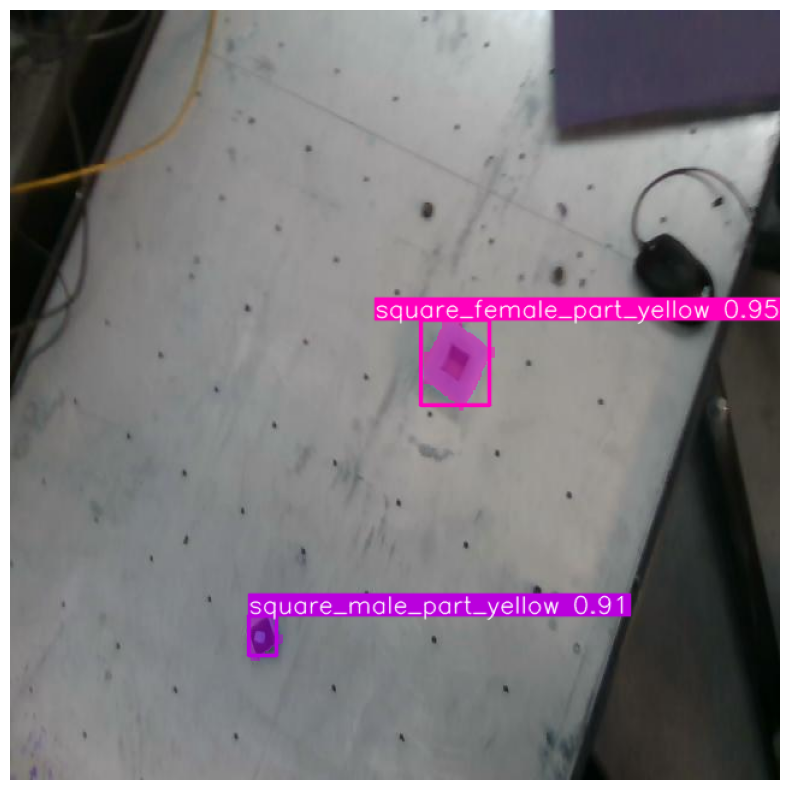

In [ ]:
# 1. Cargar el modelo que acabamos de entrenar
model_entrenado = YOLO('/content/bestv1.1_yolo.pt')

import matplotlib.pyplot as plt
import os

# 2. Hacer una predicción en una imagen de prueba del dataset
path_prueba = f"{dataset.location}/test/images/108_seg_1777308317s_png.rf.58ecd6c15c5b55219949843d556c29f3.jpg"
img_test = path_prueba

results_pred = model_entrenado(img_test)

# 3. Mostrar la imagen con las máscaras y etiquetas
for r in results_pred:
    im_array = r.plot()  # r.plot() dibuja las máscaras y cajas automáticamente
    plt.figure(figsize=(10, 10))
    plt.imshow(im_array)
    plt.axis('off')
    plt.show()

prueba para checar centroide


image 1/1 /content/ensamble-1/test/images/saved_image_156_png.rf.82d03263d452e5e0d175e5ca1ac6a00d.jpg: 640x640 1 circulo_a, 1 circulo_b, 2 cuadro_as, 1 cuadro_c_a, 1 hembra_circulo_a, 1 hembra_circulo_b, 1 hembra_cuadro_a, 1 hembra_cuadro_b, 1 hembra_cuadro_c_a, 1 hembra_cuadro_c_b, 11.9ms
Speed: 2.8ms preprocess, 11.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Objeto: hembra_cuadro_c_a | Centroide: (238, 348)
Objeto: hembra_cuadro_a | Centroide: (156, 45)
Objeto: hembra_circulo_a | Centroide: (147, 276)
Objeto: circulo_b | Centroide: (282, 408)
Objeto: hembra_cuadro_b | Centroide: (216, 225)
Objeto: hembra_circulo_b | Centroide: (97, 256)
Objeto: hembra_cuadro_c_b | Centroide: (111, 157)
Objeto: circulo_a | Centroide: (278, 189)
Objeto: cuadro_a | Centroide: (231, 162)
Objeto: cuadro_a | Centroide: (242, 287)
Objeto: cuadro_c_a | Centroide: (278, 189)


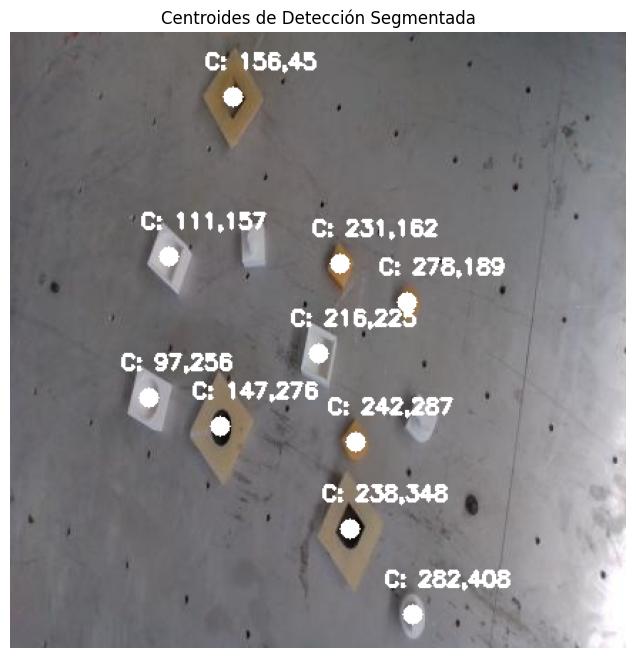

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Ejecutar la predicción
results = model.predict(source="/content/ensamble-1/test/images/saved_image_156_png.rf.82d03263d452e5e0d175e5ca1ac6a00d.jpg", conf=0.5)

for r in results:
    img_bgr = cv2.imread(r.path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Verificamos si hay máscaras en la detección
    if r.masks is not None:
        # Extraemos las coordenadas de los polígonos
        masks = r.masks.xy

        for i, mask in enumerate(masks):
            # 2. CALCULAR EL CENTROIDE USANDO MOMENTOS
            # Convertimos la máscara a float32 para OpenCV
            M = cv2.moments(mask.astype(np.float32))

            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
            else:
                cX, cY = 0, 0

            # 3. OBTENER INFORMACIÓN DE LA CLASE
            label = r.names[int(r.boxes[i].cls)]

            print(f"Objeto: {label} | Centroide: ({cX}, {cY})")

            # 4. VISUALIZACIÓN
            # Dibujamos un punto en el centroide
            cv2.circle(img_rgb, (cX, cY), 7, (255, 255, 255), -1)
            cv2.putText(img_rgb, f"C: {cX},{cY}", (cX - 20, cY - 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    # Mostrar la imagen con los puntos marcados
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title("Centroides de Detección Segmentada")
    plt.axis('off')
    plt.show()

graficas utilizando test


✅ Modelo cargado | 12 clases:
   0: circular_female_part_white
   1: circular_female_part_yellow
   2: circular_male_part_white
   3: circular_male_part_yellow
   4: circular_square_female_part_white
   5: circular_square_female_part_yellow
   6: circular_square_male_part_white
   7: circular_square_male_part_yellow
   8: square_female_part_white
   9: square_female_part_yellow
   10: square_male_part_white
   11: square_male_part_yellow
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n-seg summary (fused): 114 layers, 2,836,908 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1810.2±1011.5 MB/s, size: 60.5 KB)
val: Scanning /content/YOLOV4.v1-v4.yolov8/test/labels... 1205 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1205/1205 1.8Kit/s 0.7s
val: New cache created: /content/YOLOV4.v1-v4.yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)  

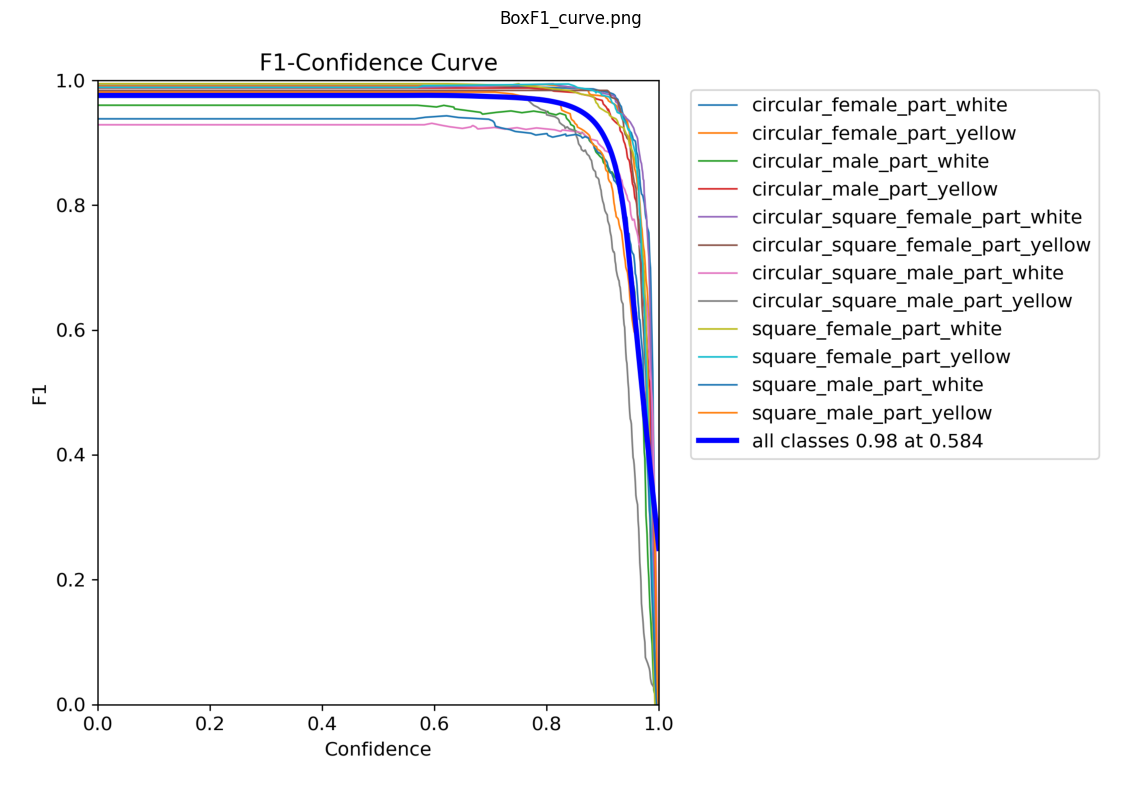

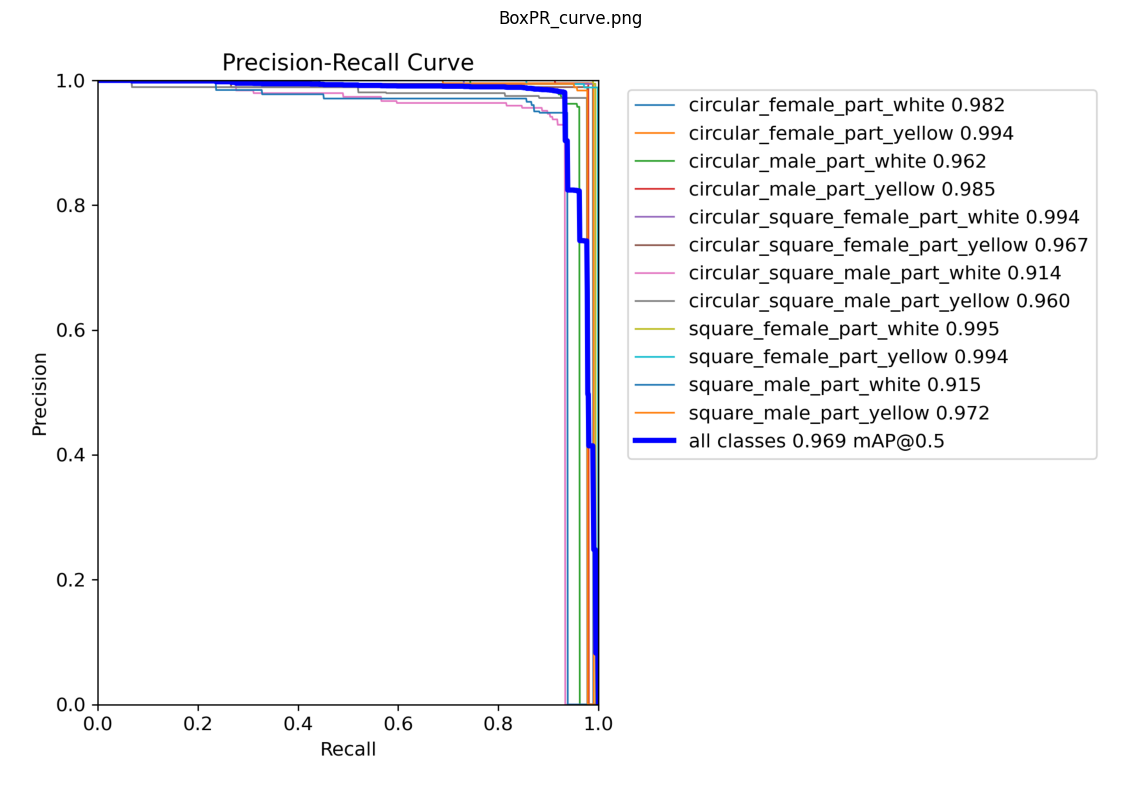

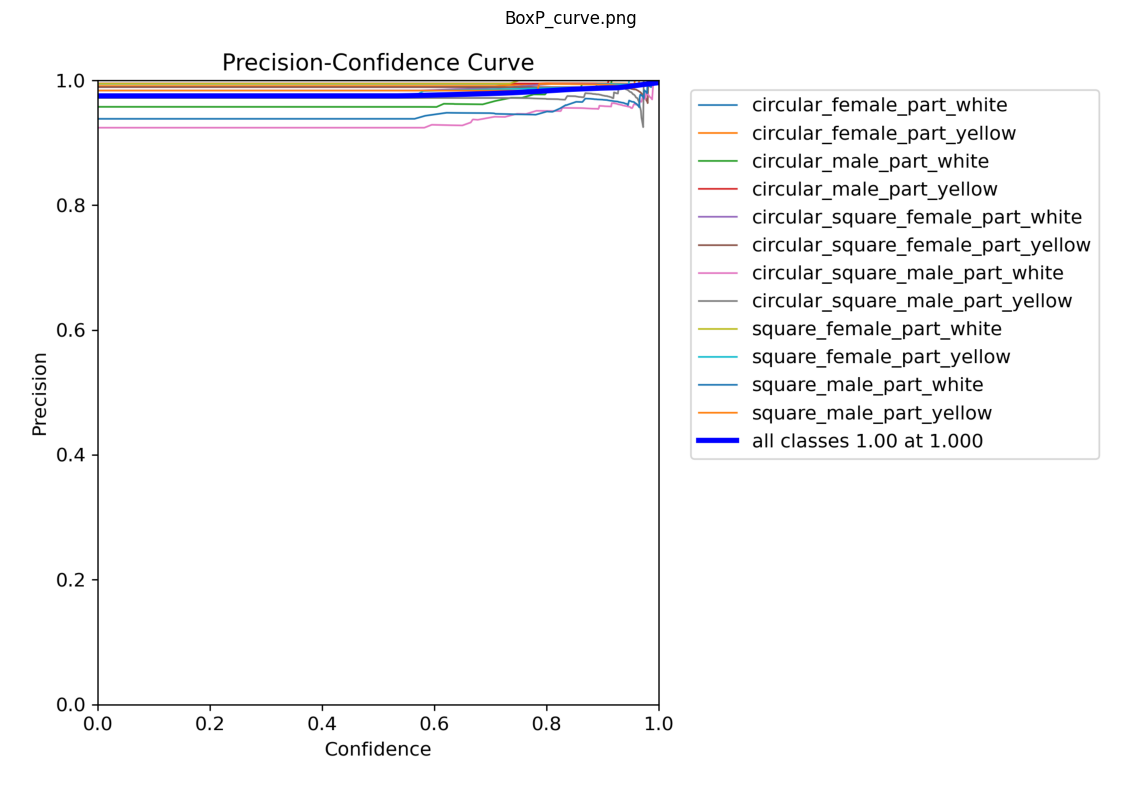

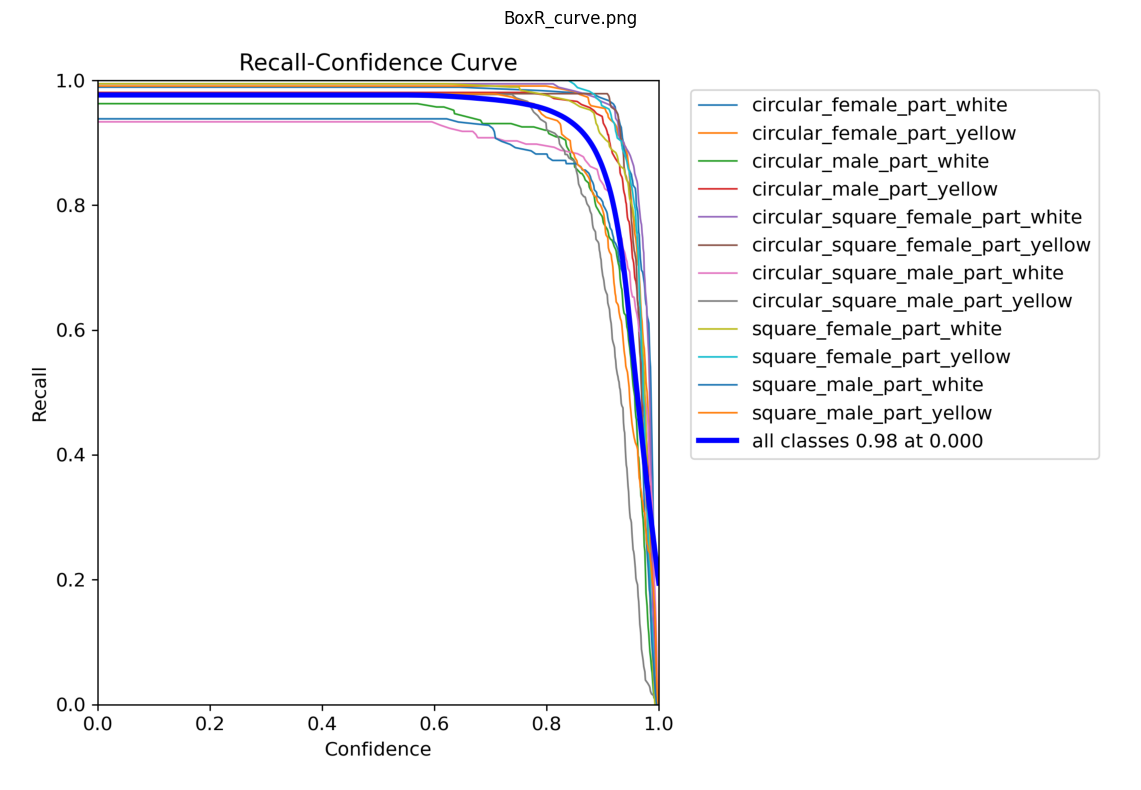

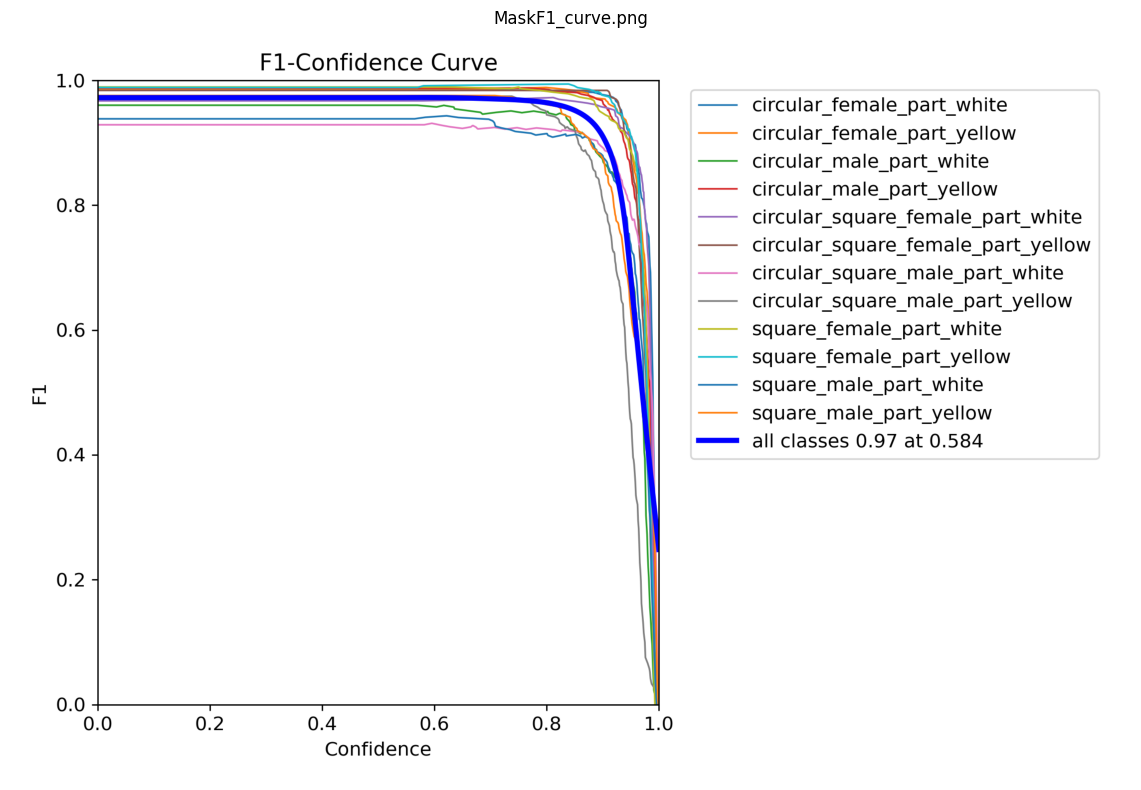

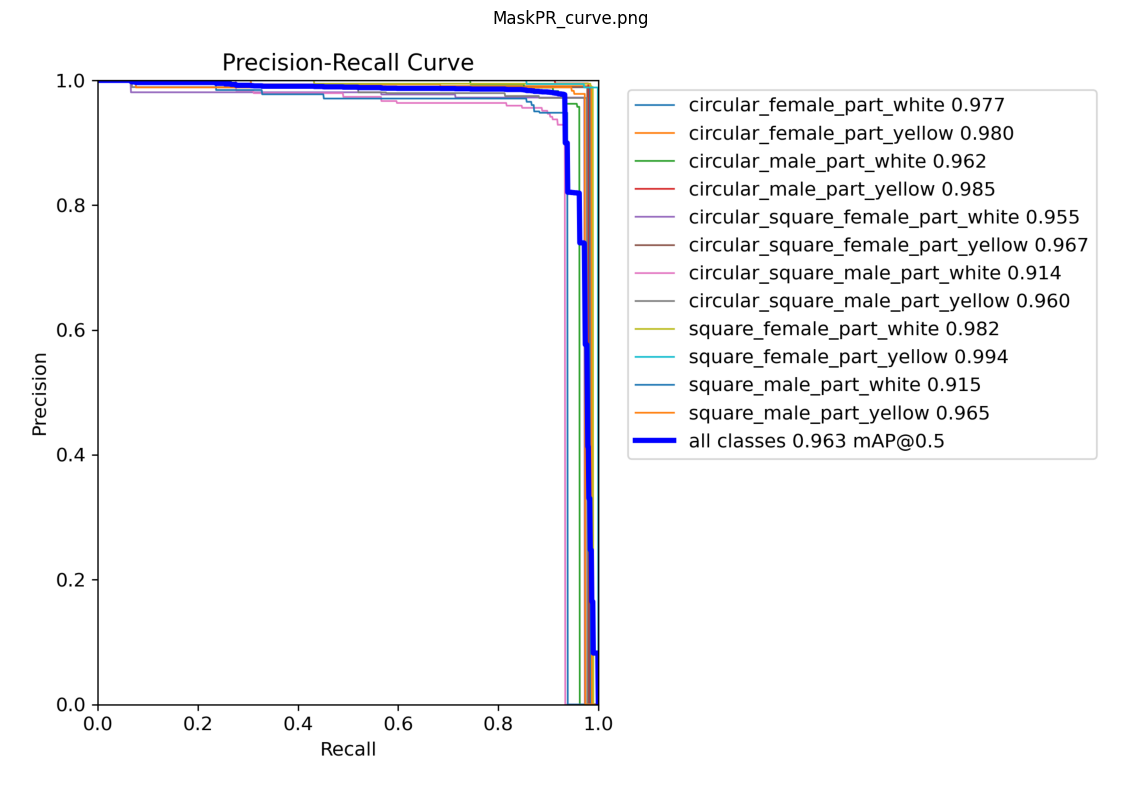

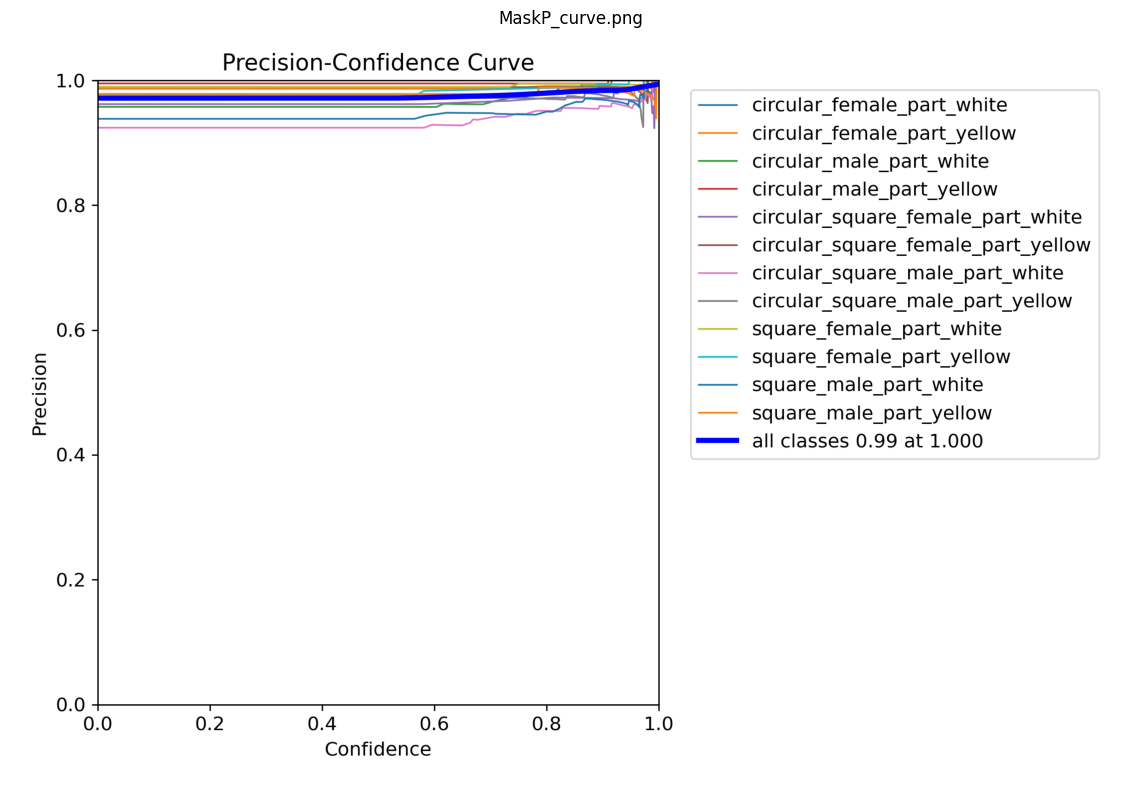

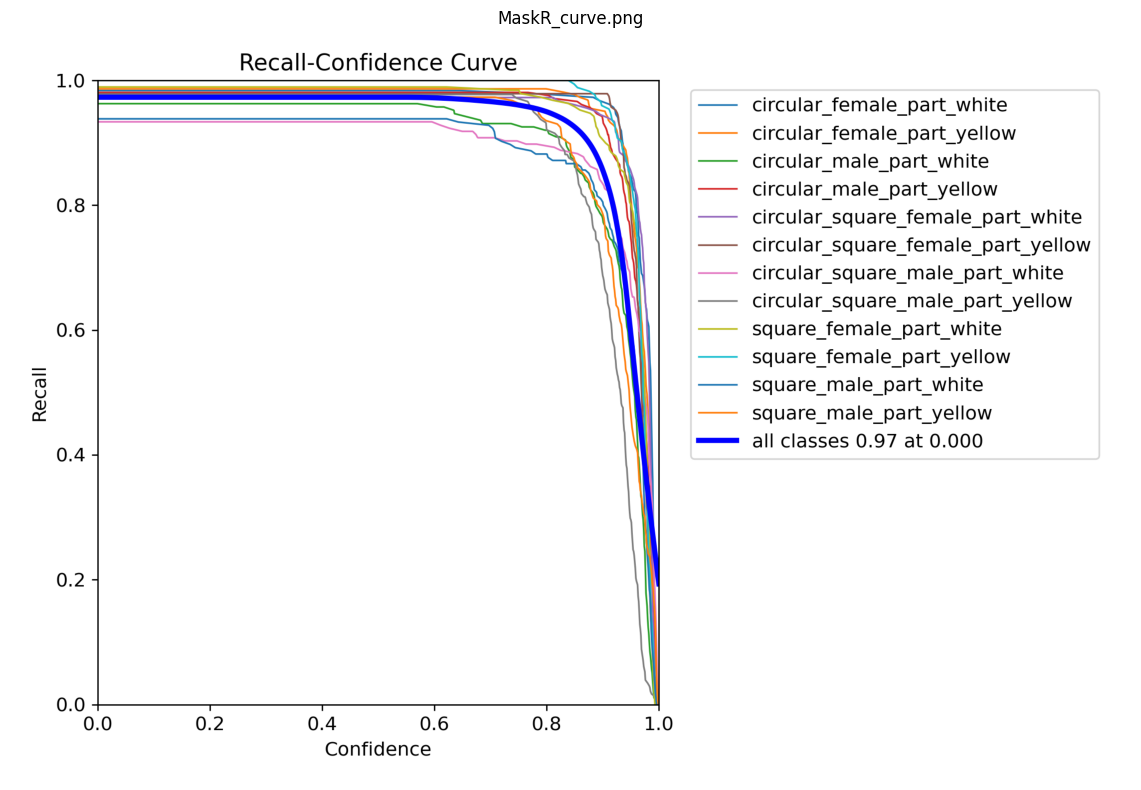

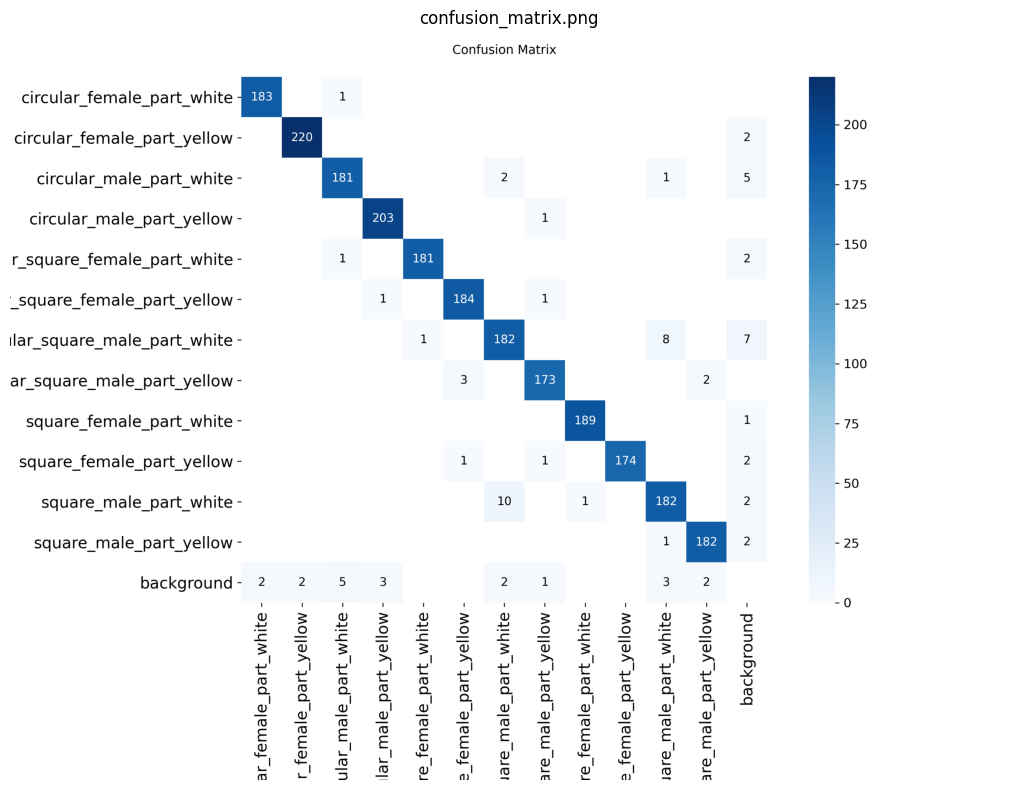

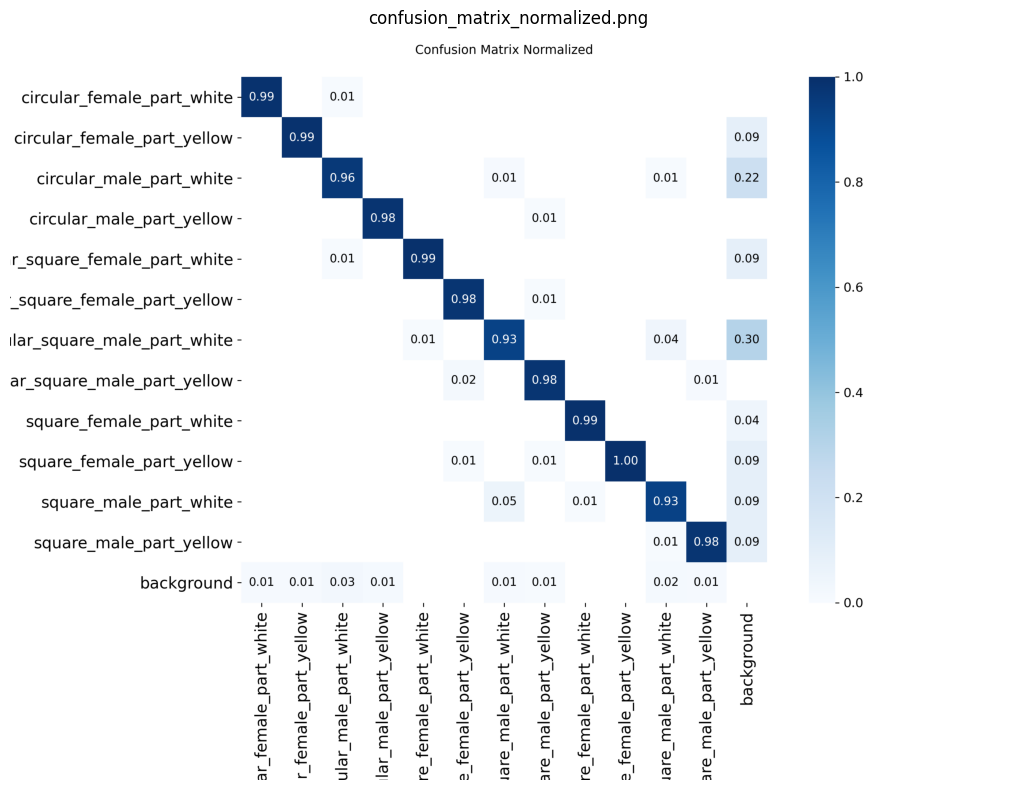

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Descarga iniciada: resultados_test.zip


In [ ]:
import ultralytics
from ultralytics import YOLO
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil
from google.colab import files

#Rutas
CHECKPOINT = "/content/runs/segment/manufactura/yolo_scratch_v1/weights/best.pt"
YAML_PATH  = "/content/YOLOV4.v1-v4.yolov8/data.yaml"   # se genera automáticamente con Roboflow

#Cargar modelo
model = YOLO(CHECKPOINT)
print(f"Modelo cargado | {len(model.names)} clases:")
for i, n in model.names.items():
    print(f"   {i}: {n}")

#Evaluación
metrics = model.val(
    data=YAML_PATH,
    split="test",
    imgsz=640,
    conf=0.56,
    iou=0.5,
    device="cpu",
    plots=True,
    save_json=True,
)

print(f"\n{'='*50}")
print(f"  mAP@0.5:       {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95:  {metrics.box.map:.4f}")
print(f"  Precision:     {metrics.box.mp:.4f}")
print(f"  Recall:        {metrics.box.mr:.4f}")
print(f"{'='*50}")

#Mostrar gráficas
plot_dir = sorted(glob.glob("/content/runs/segment/val*"))[-1] # Corrected path for segmentation validation plots
print(f"\nGráficas en: {plot_dir}")

for img_path in sorted(glob.glob(f"{plot_dir}/*.png")):
    img = mpimg.imread(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.split("/")[-1], fontsize=12)
    plt.tight_layout()
    plt.show()

#Descargar resultados
shutil.make_archive("/content/resultados_test", "zip", plot_dir)
files.download("/content/resultados_test.zip")
print("⬇ Descarga iniciada: resultados_test.zip")